# Лабораторная работа: Кластеризация методами k-Means и k-Medoids

## 1. Формулировка задания

1. Разработать программу, выполняющую кластеризацию заданного набора данных алгоритмами
   **k-Means** и **k-Medoids**. Параметры программы — набор данных и число кластеров $k$.
   Программа должна выдавать координаты точек и назначенные им кластеры, а также значение
   ошибки кластеризации.
2. Провести эксперименты на наборе данных `customers` (формат CSV, описание — `custmers.txt`).
3. Выполнить визуализацию результатов:
   * точечный график, на котором цвет точки отражает принадлежность кластеру;
   * зависимость ошибки кластеризации от параметра $k$.
4. Доработать программу, добавив в список её параметров **долю зашумлённых объектов**.
   Программа должна вносить шум в набор: случайным образом изменять заданную долю объектов
   (добавление/вычитание случайного числа к одной или нескольким координатам объекта).
5. Провести эксперименты, варьируя долю зашумлённых объектов (1 %, 3 %, 5 %, 10 %) и
   значение $k$ из интервала $3..9$, и визуализировать результаты указанным выше способом.

## 2. Набор данных customers

Набор содержит сведения о 850 клиентах банка. Атрибуты (из описания `custmers.txt`):

| Атрибут | Смысл |
|---|---|
| `Row`, `CustomerId` | порядковый номер строки и идентификатор клиента |
| `Age` | возраст, полных лет |
| `Education` | образование, целочисленный код 1..5 |
| `YearsEmployed` | трудовой стаж, полных лет |
| `Income` | доход, K\$ в год |
| `CardDebt` | задолженность по карте |
| `OtherDebt` | прочие задолженности |
| `Defaulted` | признавался банкротом (1.0/0.0) |
| `DebtIncomeRatio` | отношение долга к доходам, % |

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42

df = pd.read_csv("customers.csv")
print(f"Загружено объектов: {len(df)}, атрибутов: {df.shape[1]}")
missing = df.isna().sum()
print(f"Пропуски: {dict(missing[missing > 0].astype(int))}")
df.head()

Загружено объектов: 850, атрибутов: 10
Пропуски: {'Defaulted': np.int64(150)}


,Row,CustomerId,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [2]:
df.describe().round(2)

,Row,CustomerId,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,Defaulted,DebtIncomeRatio
count,850.00,850.00,850.00,850.00,850.00,850.00,850.00,850.00,700.00,850.00
mean,424.50,425.50,35.03,1.71,8.57,46.68,1.58,3.08,0.26,10.17
std,245.52,245.52,8.04,0.93,6.78,38.54,2.13,3.40,0.44,6.72
min,0.00,1.00,20.00,1.00,0.00,13.00,0.01,0.05,0.00,0.10
25%,212.25,213.25,29.00,1.00,3.00,24.00,0.38,1.05,0.00,5.10
50%,424.50,425.50,34.00,1.00,7.00,35.00,0.88,2.00,0.00,8.70
75%,636.75,637.75,41.00,2.00,13.00,55.75,1.90,3.90,1.00,13.80
max,849.00,850.00,56.00,5.00,33.00,446.00,20.56,35.20,1.00,41.30


### Подготовка признаков

Для кластеризации берутся семь содержательных числовых атрибутов. `Row` и `CustomerId` —
служебные идентификаторы, геометрического смысла не имеющие. `Defaulted` исключён из
признаков по двум причинам: он заполнен лишь у 700 клиентов из 850 и по смыслу является
внешней меткой (факт банкротства), а не координатой объекта. Ниже он используется только
для содержательной проверки полученных кластеров.

Оба алгоритма опираются на евклидово расстояние, поэтому признаки с большим разбросом
подавили бы остальные: $Income$ меняется от 13 до 446, а $Education$ — от 1 до 5. Поэтому
выполняется **z-нормировка** каждого признака:

$$z_{ij} = \frac{x_{ij} - \overline{x_j}}{\sigma_j},$$

после которой все признаки имеют нулевое среднее и единичное стандартное отклонение и
вносят в расстояние сопоставимый вклад.

In [3]:
FEATURES = ["Age", "Education", "YearsEmployed", "Income",
            "CardDebt", "OtherDebt", "DebtIncomeRatio"]

X_raw = df[FEATURES].to_numpy(float)
MEAN, STD = X_raw.mean(axis=0), X_raw.std(axis=0)
X = (X_raw - MEAN) / STD                      # нормированная матрица объект-признак

print(f"Матрица объект-признак: {X.shape[0]} объектов x {X.shape[1]} признаков")
pd.DataFrame({"Среднее (исх.)": MEAN.round(2), "Ст. отклонение (исх.)": STD.round(2),
              "Среднее (норм.)": X.mean(0).round(6), "Ст. откл. (норм.)": X.std(0).round(6)},
             index=FEATURES)

Матрица объект-признак: 850 объектов x 7 признаков


,Среднее (исх.),Ст. отклонение (исх.),Среднее (норм.),Ст. откл. (норм.)
Age,35.03,8.04,-0.0,1.0
Education,1.71,0.93,-0.0,1.0
YearsEmployed,8.57,6.77,-0.0,1.0
Income,46.68,38.52,0.0,1.0
CardDebt,1.58,2.12,-0.0,1.0
OtherDebt,3.08,3.40,-0.0,1.0
DebtIncomeRatio,10.17,6.72,0.0,1.0


## 3. Реализация алгоритмов

Мера близости объектов — евклидово расстояние в пространстве нормированных признаков:

$$d(x, y) = \sqrt{\sum_{j=1}^{m} (x_j - y_j)^2}.$$

### k-Means

Центром кластера служит **центроид** — среднее арифметическое его объектов. Алгоритм
(итерации Ллойда) минимизирует сумму квадратов внутрикластерных расстояний:

$$SSE = \sum_{j=1}^{k} \sum_{x \in C_j} d^2(x, \mu_j) \longrightarrow \min, \qquad
  \mu_j = \frac{1}{|C_j|} \sum_{x \in C_j} x.$$

Шаги: выбрать начальные центры → отнести каждый объект к ближайшему центру → пересчитать
центры как средние своих кластеров → повторять, пока $SSE$ не перестанет убывать.

### k-Medoids

Центром кластера служит **медоид** — реальный объект набора, суммарное расстояние от
которого до остальных объектов кластера минимально. Минимизируется сумма расстояний
(без возведения в квадрат):

$$E = \sum_{j=1}^{k} \sum_{x \in C_j} d(x, m_j) \longrightarrow \min, \qquad
  m_j = \arg\min_{p \in C_j} \sum_{x \in C_j} d(x, p).$$

Используется альтернирующая схема: объекты распределяются по ближайшим медоидам, затем
в каждом кластере медоид заменяется на объект с минимальной суммой расстояний до своих
соседей. Отказ от квадратов и от «виртуальных» центров делает k-Medoids заметно
устойчивее к выбросам — именно это проверяется в экспериментах с шумом.

### Инициализация

Оба алгоритма сходятся лишь к локальному минимуму и чувствительны к начальным центрам,
поэтому используется схема **k-means++** (очередной центр выбирается случайно с
вероятностью, пропорциональной квадрату расстояния до ближайшего уже выбранного центра)
и `n_init` независимых запусков, из которых берётся лучший по ошибке.

In [4]:
def pairwise_distances(A, B):
    """Матрица евклидовых расстояний между строками A и строками B."""
    d2 = ((A[:, None, :] - B[None, :, :]) ** 2).sum(axis=-1)
    return np.sqrt(np.maximum(d2, 0.0))


def kmeans_pp_init(X, k, rng, D=None):
    """k-means++: номера k стартовых объектов, разнесённых по пространству."""
    idx = [int(rng.integers(len(X)))]
    d2 = (D[idx[0]] ** 2 if D is not None else ((X - X[idx[0]]) ** 2).sum(1))
    for _ in range(k - 1):
        total = d2.sum()
        p = d2 / total if total > 0 else np.full(len(X), 1 / len(X))
        j = int(rng.choice(len(X), p=p))
        idx.append(j)
        d2 = np.minimum(d2, D[j] ** 2 if D is not None else ((X - X[j]) ** 2).sum(1))
    return np.array(idx)

In [5]:
def kmeans(X, k, seed=RANDOM_SEED, n_init=10, max_iter=300, tol=1e-9):
    """
    Кластеризация методом k-средних.
      X      — матрица объект-признак, k — число кластеров
      n_init — число запусков с разной инициализацией (берётся лучший)
    Возвращает словарь с метками, центрами, ошибкой SSE и числом итераций.
    """
    rng = np.random.default_rng(seed)
    best = None
    for _ in range(n_init):
        centers = X[kmeans_pp_init(X, k, rng)].copy()
        prev_sse, n_iter = np.inf, 0
        for n_iter in range(1, max_iter + 1):
            D = pairwise_distances(X, centers)
            labels = D.argmin(axis=1)
            sse = (D[np.arange(len(X)), labels] ** 2).sum()
            for j in range(k):                       # пересчёт центроидов
                members = labels == j
                if members.any():
                    centers[j] = X[members].mean(axis=0)
                else:                                # пустой кластер -> самый далёкий объект
                    centers[j] = X[D.min(axis=1).argmax()]
            if prev_sse - sse <= tol:
                break
            prev_sse = sse
        D = pairwise_distances(X, centers)
        labels = D.argmin(axis=1)
        sse = float((D[np.arange(len(X)), labels] ** 2).sum())
        if best is None or sse < best["error"]:
            best = {"algorithm": "k-Means", "labels": labels, "centers": centers.copy(),
                    "error": sse, "n_iter": n_iter}
    return best

In [6]:
def kmedoids(X, k, seed=RANDOM_SEED, n_init=10, max_iter=300):
    """
    Кластеризация методом k-медоидов (альтернирующая оптимизация).
    Ошибка — суммарное расстояние от объектов до медоидов своих кластеров.
    """
    rng = np.random.default_rng(seed)
    D = pairwise_distances(X, X)                     # полная матрица расстояний
    rows = np.arange(len(X))
    best = None
    for _ in range(n_init):
        medoids = kmeans_pp_init(X, k, rng, D=D)
        prev_cost, n_iter = np.inf, 0
        for n_iter in range(1, max_iter + 1):
            labels = D[:, medoids].argmin(axis=1)
            cost = D[rows, medoids[labels]].sum()
            for j in range(k):                       # новый медоид кластера
                members = np.flatnonzero(labels == j)
                if len(members):
                    medoids[j] = members[D[np.ix_(members, members)].sum(axis=0).argmin()]
                else:
                    medoids[j] = int(D[:, medoids].min(axis=1).argmax())
            if prev_cost - cost <= 1e-12:
                break
            prev_cost = cost
        labels = D[:, medoids].argmin(axis=1)
        cost = float(D[rows, medoids[labels]].sum())
        if best is None or cost < best["error"]:
            best = {"algorithm": "k-Medoids", "labels": labels, "centers": X[medoids].copy(),
                    "medoid_idx": medoids.copy(), "error": cost, "n_iter": n_iter}
    return best

## 4. Программа кластеризации

Функция `cluster()` — это и есть требуемая программа. Её параметры:

* `X` — набор данных,
* `k` — число кластеров,
* `algorithm` — `kmeans` или `kmedoids`,
* `noise_fraction` — доля зашумлённых объектов (добавлена по п. 4 задания).

### Модель шума

Выбирается случайное подмножество из $\lceil n \cdot p \rceil$ объектов. У каждого
выбранного объекта случайно выбирается от одной до всех координат, и к каждой из них
прибавляется случайная величина

$$\Delta_j = \pm\, u \cdot \sigma_j, \qquad u \sim U(2, 6),$$

где $\sigma_j$ — стандартное отклонение $j$-го признака, а знак равновероятен. Шум
задаётся в единицах $\sigma$, чтобы одинаково искажать признаки разного масштаба;
сдвиг в 2–6 $\sigma$ гарантированно выводит объект за пределы своего кластера, то есть
превращает его в выброс.

Для сравнения разбиений используется **скорректированный индекс Рэнда** (ARI): он равен 1
при полном совпадении разбиений, около 0 — при случайном совпадении, и не зависит от
нумерации кластеров.

In [7]:
NOISE_MIN, NOISE_MAX = 2.0, 6.0        # амплитуда сдвига в единицах сигма


def add_noise(X, noise_fraction, noise_seed=RANDOM_SEED):
    """Зашумить заданную долю объектов набора. Возвращает набор и номера изменённых объектов."""
    rng = np.random.default_rng(noise_seed)
    X_noisy = X.copy()
    n, m = X.shape
    n_noisy = int(np.ceil(n * noise_fraction))
    if n_noisy == 0:
        return X_noisy, np.array([], dtype=int)

    noisy_idx = rng.choice(n, size=n_noisy, replace=False)
    sigma = X.std(axis=0)
    for i in noisy_idx:
        n_coords = int(rng.integers(1, m + 1))                  # одна или несколько координат
        coords = rng.choice(m, size=n_coords, replace=False)
        delta = rng.uniform(NOISE_MIN, NOISE_MAX, size=n_coords) * rng.choice([-1, 1], n_coords)
        X_noisy[i, coords] += delta * sigma[coords]             # добавление/вычитание
    return X_noisy, np.sort(noisy_idx)


def adjusted_rand_index(a, b):
    """Мера согласия двух разбиений: 1 — совпадают, ~0 — согласие на уровне случайного."""
    a, b = np.asarray(a), np.asarray(b)
    table = np.zeros((a.max() + 1, b.max() + 1))
    np.add.at(table, (a, b), 1)
    comb2 = lambda x: x * (x - 1) / 2
    sum_ij, sum_a, sum_b = (comb2(table).sum(), comb2(table.sum(1)).sum(),
                            comb2(table.sum(0)).sum())
    expected = sum_a * sum_b / comb2(len(a))
    return float((sum_ij - expected) / ((sum_a + sum_b) / 2 - expected))


def partition_errors(X, labels):
    """
    Обе меры ошибки как характеристики разбиения, независимо от алгоритма:
      SSE — сумма квадратов расстояний до центроида кластера,
      E   — сумма расстояний до медоида кластера (лучшего объекта кластера).
    """
    sse = total = 0.0
    for j in np.unique(labels):
        points = X[labels == j]
        sse += ((points - points.mean(axis=0)) ** 2).sum()
        total += pairwise_distances(points, points).sum(axis=0).min()
    return float(sse), float(total)


def cluster(X, k, algorithm="kmeans", noise_fraction=0.0, seed=RANDOM_SEED,
            noise_seed=None, n_init=10):
    """
    Программа кластеризации.
      X, k           — набор данных и число кластеров
      algorithm      — kmeans | kmedoids
      noise_fraction — доля зашумлённых объектов
      seed           — зерно инициализации алгоритма
      noise_seed     — зерно генератора шума (по умолчанию совпадает с seed)
    """
    X_used, noisy_idx = add_noise(X, noise_fraction,
                                  noise_seed=seed if noise_seed is None else noise_seed)
    t0 = time.perf_counter()
    result = (kmeans if algorithm == "kmeans" else kmedoids)(X_used, k, seed=seed, n_init=n_init)
    result.update({"k": k, "noise_fraction": noise_fraction, "noisy_idx": noisy_idx,
                   "X": X_used, "time_sec": time.perf_counter() - t0,
                   "sizes": np.bincount(result["labels"], minlength=k)})
    return result

## 5. Результат работы программы: координаты точек, кластеры и ошибка

Запуск обоих алгоритмов при $k = 4$ на незашумлённом наборе. Программа выводит координаты
каждого объекта с назначенным ему номером кластера и значение ошибки кластеризации — каждый
алгоритм сообщает ошибку по тому функционалу, который он минимизирует.

Эти два числа несопоставимы между собой напрямую, поэтому для сравнения алгоритмов обе меры
считаются **как характеристики разбиения**: для каждого кластера берётся тот центр, который
соответствующую меру минимизирует, — центроид для $SSE$ и медоид для $E$. Полученные
значения зависят только от состава кластеров, а не от того, каким алгоритмом они найдены,
и потому сравнимы.

In [8]:
K_DEMO = 4

res_km = cluster(X, K_DEMO, "kmeans")
res_md = cluster(X, K_DEMO, "kmedoids")

for res in (res_km, res_md):
    print(f"{res['algorithm']:<10} k={res['k']}  ошибка = {res['error']:.2f}  "
          f"итераций {res['n_iter']:>2}  время {res['time_sec']:.2f} с  "
          f"размеры кластеров {res['sizes'].tolist()}")

print(f"\nARI между разбиениями: "
      f"{adjusted_rand_index(res_km['labels'], res_md['labels']):.3f}\n")

comparison = pd.DataFrame(
    [dict(zip(["Метод", "SSE (центроиды)", "E (медоиды)"],
              [res["algorithm"], *partition_errors(X, res["labels"])]))
     for res in (res_km, res_md)]).set_index("Метод")
comparison["Лучше по SSE"] = comparison["SSE (центроиды)"] == comparison["SSE (центроиды)"].min()
comparison["Лучше по E"] = comparison["E (медоиды)"] == comparison["E (медоиды)"].min()
comparison.round(2)

k-Means    k=4  ошибка = 3232.71  итераций 14  время 0.03 с  размеры кластеров [150, 217, 54, 429]
k-Medoids  k=4  ошибка = 1495.40  итераций  6  время 0.06 с  размеры кластеров [247, 131, 215, 257]

ARI между разбиениями: 0.362



,SSE (центроиды),E (медоиды),Лучше по SSE,Лучше по E
Метод,,,,
k-Means,3232.71,1575.96,True,False
k-Medoids,3417.22,1495.40,False,True


In [9]:
# Координаты точек и назначенные им кластера (п. 1 задания)
assignment = df[["CustomerId"]].join(pd.DataFrame(X_raw, columns=FEATURES))
assignment["Кластер k-Means"] = res_km["labels"]
assignment["Кластер k-Medoids"] = res_md["labels"]

print(f"Всего строк: {len(assignment)}; показаны первые 15")
assignment.head(15)

Всего строк: 850; показаны первые 15


,CustomerId,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,DebtIncomeRatio,Кластер k-Means,Кластер k-Medoids
0,1,41.0,2.0,6.0,19.0,0.124,1.073,6.3,3,3
1,2,47.0,1.0,26.0,100.0,4.582,8.218,12.8,2,1
2,3,33.0,2.0,10.0,57.0,6.111,5.802,20.9,0,1
3,4,29.0,2.0,4.0,19.0,0.681,0.516,6.3,3,0
4,5,47.0,1.0,31.0,253.0,9.308,8.908,7.2,2,1
5,6,40.0,1.0,23.0,81.0,0.998,7.831,10.9,1,2
6,7,38.0,2.0,4.0,56.0,0.442,0.454,1.6,3,0
7,8,42.0,3.0,0.0,64.0,0.279,3.945,6.6,3,0
8,9,26.0,1.0,5.0,18.0,0.575,2.215,15.5,3,3
9,10,47.0,3.0,23.0,115.0,0.653,3.947,4.0,1,2


### Содержательный смысл кластеров

Для интерпретации центроиды переведены обратно в исходные единицы. Столбец `Defaulted` —
доля клиентов кластера, признававшихся банкротами; в кластеризации этот атрибут не
участвовал, поэтому служит независимой проверкой осмысленности разбиения.

In [10]:
def cluster_profile(labels, title):
    prof = pd.DataFrame(X_raw, columns=FEATURES).groupby(labels).mean().round(2)
    prof.insert(0, "Объектов", np.bincount(labels))
    prof["Доля банкротов"] = df["Defaulted"].groupby(labels).mean().round(3)
    prof.index.name = f"{title}: кластер"
    return prof


display(cluster_profile(res_km["labels"], "k-Means"))
display(cluster_profile(res_md["labels"], "k-Medoids"))

,Объектов,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,DebtIncomeRatio,Доля банкротов
k-Means: кластер,,,,,,,,,
0,150,34.07,1.88,6.36,37.84,2.39,4.74,19.50,0.512
1,217,42.38,1.65,15.04,68.37,1.47,3.05,7.20,0.083
2,54,43.63,2.04,18.37,127.48,7.12,11.95,17.89,0.409
3,429,30.56,1.64,4.83,28.62,0.65,1.39,7.44,0.238


,Объектов,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,DebtIncomeRatio,Доля банкротов
k-Medoids: кластер,,,,,,,,,
0,247,30.53,2.50,3.83,32.51,1.00,2.13,10.27,0.373
1,131,40.83,2.12,15.24,99.12,4.91,8.76,16.41,0.345
2,215,41.89,1.39,13.76,56.11,1.20,2.62,7.81,0.096
3,257,30.66,1.02,5.37,25.67,0.75,1.48,8.88,0.237


## 6. Визуализация: точечный график

Объекты описываются семью признаками, поэтому для точечного графика нужна проекция на
плоскость. Используется **метод главных компонент** (PCA): данные проецируются на два
ортогональных направления максимальной дисперсии, вычисляемых через сингулярное
разложение центрированной матрицы $X = U S V^{T}$ (строки $V^{T}$ — главные компоненты).
Такая проекция сохраняет наибольшую долю исходной изменчивости, а значит и взаимное
расположение кластеров. Цвет точки отражает принадлежность кластеру, крупные маркеры —
центроиды (k-Means) и медоиды (k-Medoids).

In [11]:
PALETTE = ["#337ab7", "#d9534f", "#5cb85c", "#f0ad4e", "#9b59b6",
           "#17a2b8", "#e83e8c", "#6c757d", "#8c564b"]


def fit_pca(X):
    """Две главные компоненты: функция проекции и доли объяснённой дисперсии."""
    center = X.mean(axis=0)
    _, S, Vt = np.linalg.svd(X - center, full_matrices=False)
    components = Vt[:2] * np.sign(Vt[:2, np.abs(Vt[:2]).argmax(axis=1)].diagonal())[:, None]
    ratio = S ** 2 / (S ** 2).sum()
    return (lambda Y: (Y - center) @ components.T), ratio, components


project, var_ratio, components = fit_pca(X)

print("Доля объяснённой дисперсии по компонентам:", var_ratio.round(3))
print(f"Первые две компоненты объясняют {var_ratio[:2].sum():.1%} изменчивости\n")
display(pd.DataFrame(components.T, index=FEATURES,
                     columns=["PC1", "PC2"]).round(2).T)

Доля объяснённой дисперсии по компонентам: [0.441 0.21  0.155 0.083 0.051 0.042 0.017]
Первые две компоненты объясняют 65.1% изменчивости



,Age,Education,YearsEmployed,Income,CardDebt,OtherDebt,DebtIncomeRatio
PC1,0.35,0.08,0.40,0.46,0.45,0.48,0.23
PC2,-0.38,0.16,-0.42,-0.25,0.27,0.27,0.67


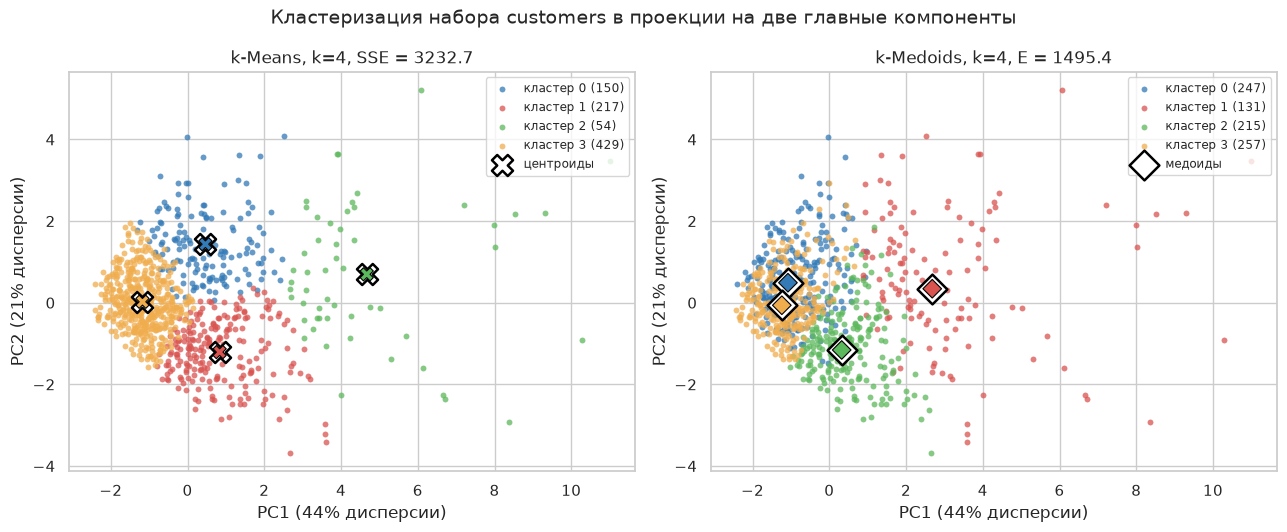

In [12]:
def scatter_clusters(ax, P, labels, centers_P=None, noisy_idx=None, title="",
                     center_marker="X", center_label="центроиды", legend=True):
    """Точечный график: цвет точки — номер кластера."""
    for j in range(labels.max() + 1):
        m = labels == j
        ax.scatter(P[m, 0], P[m, 1], s=18, alpha=0.75, linewidths=0,
                   color=PALETTE[j % len(PALETTE)], label=f"кластер {j} ({m.sum()})")
    if noisy_idx is not None and len(noisy_idx):
        ax.scatter(P[noisy_idx, 0], P[noisy_idx, 1], s=52, facecolors="none",
                   edgecolors="#222222", linewidths=0.9, label=f"шум ({len(noisy_idx)})")
    if centers_P is not None:
        ax.scatter(centers_P[:, 0], centers_P[:, 1], s=230, marker=center_marker,
                   c="white", edgecolors="black", linewidths=1.8, zorder=5,
                   label=center_label)
        ax.scatter(centers_P[:, 0], centers_P[:, 1], s=90, marker=center_marker,
                   c=[PALETTE[j % len(PALETTE)] for j in range(len(centers_P))],
                   edgecolors="black", linewidths=0.8, zorder=6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f"PC1 ({var_ratio[0]:.0%} дисперсии)")
    ax.set_ylabel(f"PC2 ({var_ratio[1]:.0%} дисперсии)")
    if legend:
        ax.legend(fontsize=8.5, loc="best")


P = project(X)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
scatter_clusters(axes[0], P, res_km["labels"], project(res_km["centers"]),
                 title=f"k-Means, k={K_DEMO}, SSE = {res_km['error']:.1f}")
scatter_clusters(axes[1], P, res_md["labels"], project(res_md["centers"]),
                 title=f"k-Medoids, k={K_DEMO}, E = {res_md['error']:.1f}",
                 center_marker="D", center_label="медоиды")
fig.suptitle("Кластеризация набора customers в проекции на две главные компоненты",
             fontsize=13.5)
fig.tight_layout()
plt.show()

### Тот же результат в исходных координатах

Проекция PCA удобна, но её оси — линейные комбинации признаков. Ниже разбиение k-Means
показано в парах исходных атрибутов, что позволяет прочитать смысл кластеров напрямую.

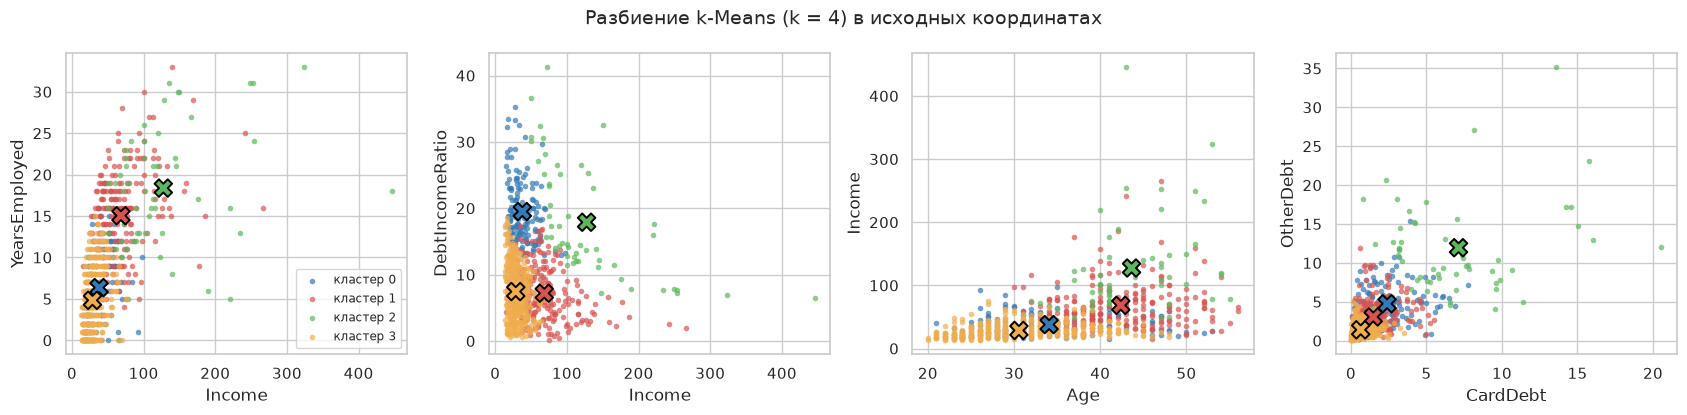

In [13]:
PAIRS = [("Income", "YearsEmployed"), ("Income", "DebtIncomeRatio"),
         ("Age", "Income"), ("CardDebt", "OtherDebt")]

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (fx, fy) in zip(axes, PAIRS):
    ix, iy = FEATURES.index(fx), FEATURES.index(fy)
    for j in range(K_DEMO):
        m = res_km["labels"] == j
        ax.scatter(X_raw[m, ix], X_raw[m, iy], s=16, alpha=0.7, linewidths=0,
                   color=PALETTE[j], label=f"кластер {j}")
    centers_raw = res_km["centers"] * STD + MEAN
    ax.scatter(centers_raw[:, ix], centers_raw[:, iy], s=160, marker="X",
               c=PALETTE[:K_DEMO], edgecolors="black", linewidths=1.4, zorder=5)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)

axes[0].legend(fontsize=8.5)
fig.suptitle("Разбиение k-Means (k = 4) в исходных координатах", fontsize=13.5)
fig.tight_layout()
plt.show()

## 7. Зависимость ошибки кластеризации от числа кластеров

Ошибка обоих алгоритмов монотонно убывает с ростом $k$ — при $k = n$ она обратилась бы в
нуль, поэтому по минимуму ошибки выбрать $k$ нельзя. Используется **метод локтя**: разумным
считается значение $k$, после которого убывание ошибки резко замедляется. Количественно
излом находится как точка максимального удаления кривой от прямой, соединяющей её концы.

In [14]:
K_RANGE = list(range(1, 13))

rows = []
for k in K_RANGE:
    r_km, r_md = cluster(X, k, "kmeans"), cluster(X, k, "kmedoids")
    rows.append({"k": k, "SSE (k-Means)": r_km["error"], "E (k-Medoids)": r_md["error"],
                 "Итераций k-Means": r_km["n_iter"], "Итераций k-Medoids": r_md["n_iter"],
                 "Время, с": r_km["time_sec"] + r_md["time_sec"]})

df_elbow = pd.DataFrame(rows)


def elbow_k(ks, errors):
    """Точка наибольшего отклонения кривой ошибки от хорды между её концами."""
    ks, errors = np.asarray(ks, float), np.asarray(errors, float)
    x = (ks - ks[0]) / (ks[-1] - ks[0])
    y = (errors - errors[-1]) / (errors[0] - errors[-1])
    return int(ks[((1 - x) - y).argmax()])      # кривая выпукла и лежит ниже хорды


ELBOW_KM = elbow_k(df_elbow["k"], df_elbow["SSE (k-Means)"])
ELBOW_MD = elbow_k(df_elbow["k"], df_elbow["E (k-Medoids)"])
print(f"Локоть кривой ошибки: k-Means k = {ELBOW_KM}, k-Medoids k = {ELBOW_MD}")
df_elbow.round(2)

Локоть кривой ошибки: k-Means k = 4, k-Medoids k = 4


,k,SSE (k-Means),E (k-Medoids),Итераций k-Means,Итераций k-Medoids,"Время, с"
0,1,5950.00,2008.17,3,3,0.09
1,2,4343.95,1757.61,14,3,0.08
2,3,3702.42,1608.29,10,4,0.09
3,4,3232.71,1495.40,14,6,0.09
4,5,2869.02,1472.08,20,4,0.09
5,6,2603.25,1383.92,20,7,0.10
6,7,2400.19,1356.47,20,5,0.11
7,8,2273.63,1309.10,13,4,0.11
8,9,2167.60,1279.98,29,4,0.12
9,10,2051.62,1258.00,26,3,0.11


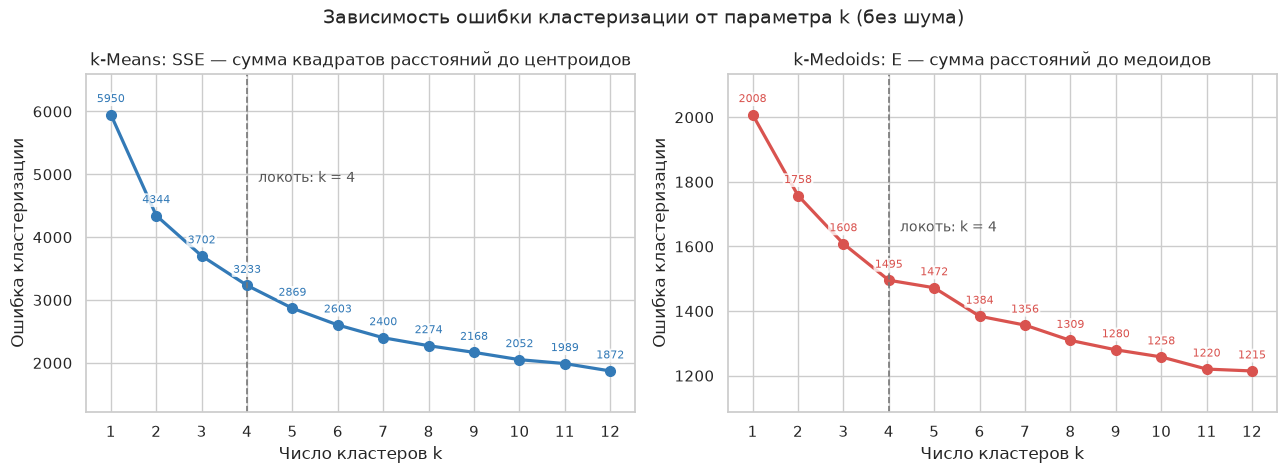

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
curves = [("SSE (k-Means)", "k-Means: SSE — сумма квадратов расстояний до центроидов",
           "#337ab7", ELBOW_KM),
          ("E (k-Medoids)", "k-Medoids: E — сумма расстояний до медоидов",
           "#d9534f", ELBOW_MD)]

for ax, (col, title, color, k_elbow) in zip(axes, curves):
    ax.plot(df_elbow["k"], df_elbow[col], marker="o", markersize=7,
            linewidth=2.3, color=color)
    ax.axvline(k_elbow, color="#777777", linestyle="--", linewidth=1.2)
    ax.annotate(f"локоть: k = {k_elbow}", (k_elbow, df_elbow[col].max() * 0.82),
                xytext=(8, 0), textcoords="offset points", fontsize=10, color="#555555")
    for _, row in df_elbow.iterrows():
        ax.annotate(f"{row[col]:.0f}", (row["k"], row[col]), fontsize=8,
                    textcoords="offset points", xytext=(0, 9), ha="center", color=color,
                    bbox=dict(boxstyle="round,pad=0.12", fc="white", ec="none", alpha=0.8))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Число кластеров k")
    ax.set_ylabel("Ошибка кластеризации")
    ax.set_xticks(K_RANGE)
    ax.margins(y=0.16)

fig.suptitle("Зависимость ошибки кластеризации от параметра k (без шума)", fontsize=13.5)
fig.tight_layout()
plt.show()

## 8. Внесение шума в набор данных

Ниже показано действие модели шума: при доле 10 % изменяются 85 объектов, каждый из
которых сдвигается на 2–6 $\sigma$ по одной или нескольким координатам. Зашумлённые
объекты обведены контуром.

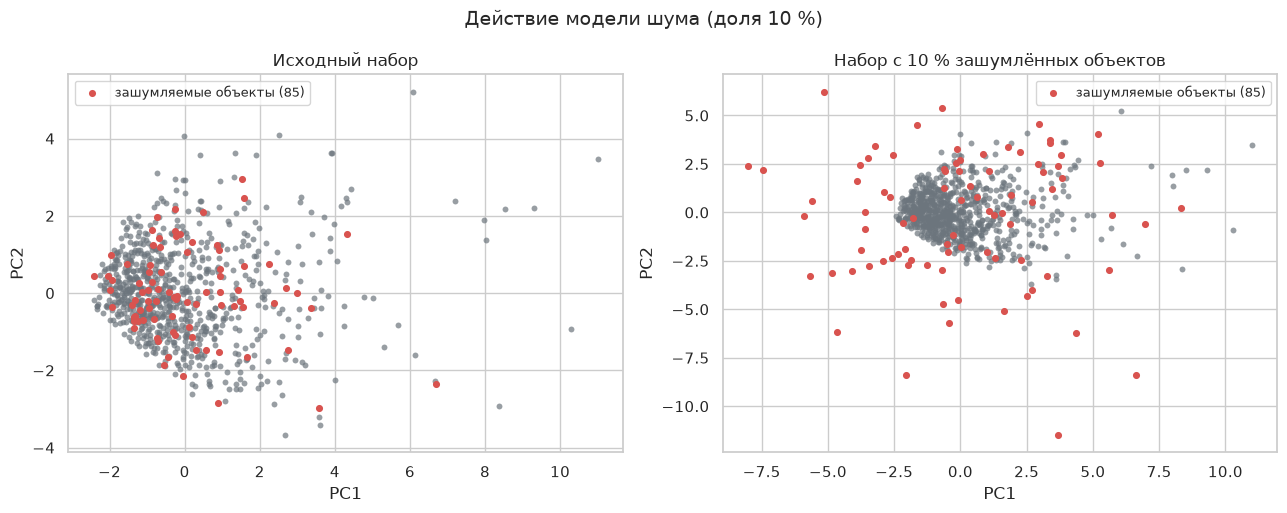

Изменено объектов: 85 из 850
Разброс данных до шума:   std по признакам = [1. 1. 1. 1. 1. 1. 1.]
Разброс данных после шума: std по признакам = [1.37 1.4  1.44 1.42 1.33 1.55 1.39]


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
X_noisy_demo, noisy_demo = add_noise(X, 0.10)
P_noisy = project(X_noisy_demo)

for ax, (P_cur, title) in zip(axes, [(P, "Исходный набор"),
                                     (P_noisy, "Набор с 10 % зашумлённых объектов")]):
    ax.scatter(P_cur[:, 0], P_cur[:, 1], s=18, alpha=0.7, linewidths=0, color="#6c757d")
    ax.scatter(P_cur[noisy_demo, 0], P_cur[noisy_demo, 1], s=26, color="#d9534f",
               linewidths=0, label=f"зашумляемые объекты ({len(noisy_demo)})")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=9)

fig.suptitle("Действие модели шума (доля 10 %)", fontsize=13.5)
fig.tight_layout()
plt.show()

print(f"Изменено объектов: {len(noisy_demo)} из {len(X)}")
print(f"Разброс данных до шума:   std по признакам = {X.std(0).round(2)}")
print(f"Разброс данных после шума: std по признакам = {X_noisy_demo.std(0).round(2)}")

## 9. Эксперименты при различных долях шума и k = 3..9

Доля зашумлённых объектов меняется в ряду 0 %, 1 %, 3 %, 5 %, 10 %, число кластеров — от 3
до 9. Шум случаен, поэтому каждое сочетание повторяется `N_REPEATS` раз с разными
реализациями шума, а результаты усредняются. Зерно инициализации алгоритма при этом
**фиксировано**: иначе разброс результатов смешивал бы влияние шума с влиянием случайного
старта.

Помимо ошибки фиксируется ARI между разбиением зашумлённого набора и эталонным разбиением
чистого набора при том же $k$: он показывает, насколько шум меняет сам состав кластеров, а
не только величину ошибки. Чтобы этот показатель можно было правильно прочитать, отдельно
измеряется **собственная неустойчивость** каждого алгоритма — ARI между разбиениями одного
и того же чистого набора, полученными при разных зёрнах инициализации. Она задаёт уровень,
ниже которого расхождение уже нельзя приписывать шуму.

In [17]:
NOISE_LEVELS = [0.0, 0.01, 0.03, 0.05, 0.10]
K_NOISE = list(range(3, 10))
N_REPEATS = 5

baseline = {k: {a: cluster(X, k, a)["labels"] for a in ("kmeans", "kmedoids")}
            for k in K_NOISE}

records = []
t0 = time.perf_counter()
for noise in NOISE_LEVELS:
    for k in K_NOISE:
        for algorithm in ("kmeans", "kmedoids"):
            for rep in range(N_REPEATS if noise > 0 else 1):
                res = cluster(X, k, algorithm, noise_fraction=noise,
                              seed=RANDOM_SEED, noise_seed=RANDOM_SEED + 1000 * rep)
                records.append({"noise": noise, "k": k, "algorithm": algorithm,
                                "error": res["error"], "rep": rep,
                                "ari": adjusted_rand_index(baseline[k][algorithm],
                                                           res["labels"]),
                                "max_size": res["sizes"].max() / len(X),
                                "min_size": res["sizes"].min()})
    print(f"доля шума {noise:4.0%} — готово")

# собственная неустойчивость алгоритма: разные зёрна инициализации на чистом наборе
INIT_SEEDS = [RANDOM_SEED + 1000 * r for r in range(1, N_REPEATS + 1)]
self_ari = {}
for algorithm in ("kmeans", "kmedoids"):
    vals = [adjusted_rand_index(baseline[k][algorithm],
                                cluster(X, k, algorithm, seed=s)["labels"])
            for k in K_NOISE for s in INIT_SEEDS]
    self_ari[algorithm] = float(np.mean(vals))

df_runs = pd.DataFrame(records)
df_noise = (df_runs.groupby(["algorithm", "noise", "k"])
            .agg(error=("error", "mean"), error_std=("error", "std"),
                 ari=("ari", "mean"), min_size=("min_size", "mean"))
            .reset_index().fillna(0.0))
print(f"\nВыполнено запусков: {len(df_runs)} за {time.perf_counter() - t0:.1f} с")
print("Собственная неустойчивость (ARI между запусками на чистом наборе, k = 3..9):")
for algorithm, value in self_ari.items():
    print(f"  {algorithm:<9} {value:.3f}")

доля шума   0% — готово


доля шума   1% — готово


доля шума   3% — готово


доля шума   5% — готово


доля шума  10% — готово



Выполнено запусков: 294 за 20.7 с
Собственная неустойчивость (ARI между запусками на чистом наборе, k = 3..9):
  kmeans    0.825
  kmedoids  0.453


In [18]:
ALG_LABEL = {"kmeans": "k-Means (SSE)", "kmedoids": "k-Medoids (E)"}

pivot = (df_noise.pivot_table(index=["algorithm", "k"], columns="noise", values="error")
         .round(1))
pivot.columns = [f"шум {c:.0%}" for c in pivot.columns]
pivot.index = pd.MultiIndex.from_tuples([(ALG_LABEL[a], k) for a, k in pivot.index],
                                        names=["Алгоритм", "k"])
display(pivot)

growth = (df_noise[df_noise["noise"] == 0.10].set_index(["algorithm", "k"])["error"] /
          df_noise[df_noise["noise"] == 0.0].set_index(["algorithm", "k"])["error"])
print("Во сколько раз ошибка при 10 % шума больше, чем без шума:")
for algorithm in ("kmeans", "kmedoids"):
    vals = growth.loc[algorithm]
    print(f"  {ALG_LABEL[algorithm]:<16} от {vals.min():.2f} до {vals.max():.2f} раз "
          f"(в среднем {vals.mean():.2f})")

шум 0%  шум 1%  шум 3%  шум 5%  шум 10%
Алгоритм      k                                         
k-Means (SSE) 3  3702.4  4269.8  5325.0  6515.5   8799.7
              4  3232.7  3773.8  4797.3  5951.0   8191.2
              5  2869.0  3399.2  4394.6  5522.4   7705.1
              6  2603.3  3117.8  4098.5  5231.3   7267.5
              7  2400.2  2913.8  3847.6  4965.5   6937.5
              8  2273.6  2745.6  3677.4  4774.0   6645.8
              9  2167.6  2644.1  3532.5  4572.6   6336.7
k-Medoids (E) 3  1608.3  1651.4  1767.5  1867.3   2137.1
              4  1495.4  1562.8  1672.6  1794.4   2071.2
              5  1472.1  1479.6  1608.3  1722.7   1990.7
              6  1383.9  1446.1  1551.5  1692.1   1969.4
              7  1356.5  1413.7  1530.3  1648.8   1923.5
              8  1309.1  1378.8  1480.9  1617.0   1833.0
              9  1280.0  1351.5  1464.2  1590.8   1835.2

Во сколько раз ошибка при 10 % шума больше, чем без шума:
  k-Means (SSE)    от 2.38 до 2.92 раз (в среднем 2.73)
  k-Medoids (E)    от 1.33 до 1.43 раз (в среднем 1.39)


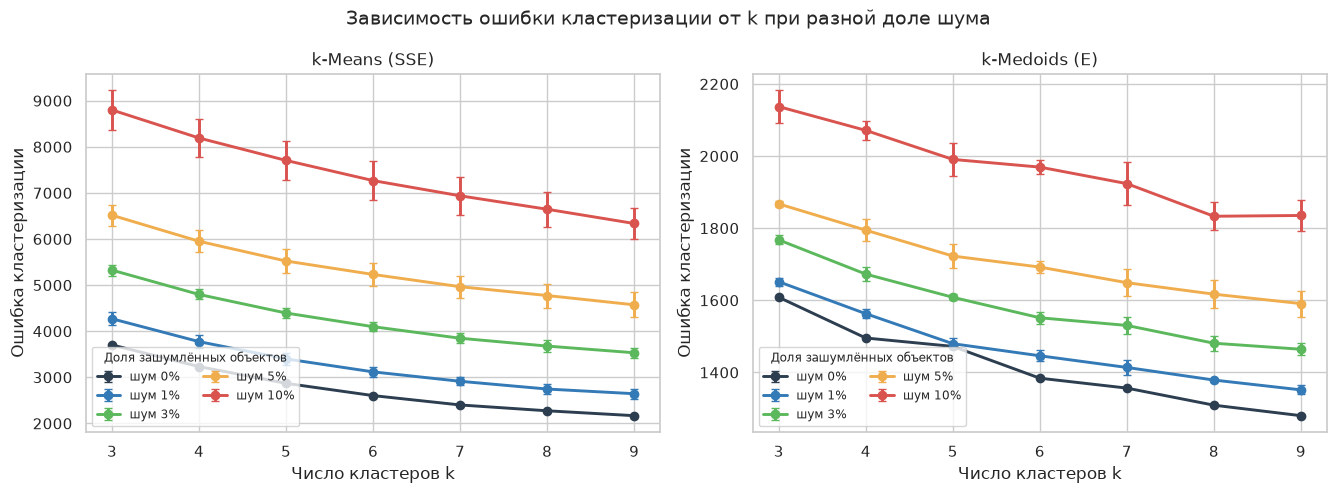

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
noise_colors = {0.0: "#2c3e50", 0.01: "#337ab7", 0.03: "#5cb85c",
                0.05: "#f0ad4e", 0.10: "#d9534f"}

for ax, algorithm in zip(axes, ("kmeans", "kmedoids")):
    sub_alg = df_noise[df_noise["algorithm"] == algorithm]
    for noise in NOISE_LEVELS:
        sub = sub_alg[sub_alg["noise"] == noise]
        ax.errorbar(sub["k"], sub["error"], yerr=sub["error_std"], marker="o",
                    markersize=6, linewidth=2.1, capsize=3,
                    color=noise_colors[noise], label=f"шум {noise:.0%}")
    ax.set_title(ALG_LABEL[algorithm], fontsize=12.5)
    ax.set_xlabel("Число кластеров k")
    ax.set_ylabel("Ошибка кластеризации")
    ax.set_xticks(K_NOISE)
    ax.legend(fontsize=8.5, loc="lower left", title="Доля зашумлённых объектов",
              title_fontsize=8.5, ncol=2)

fig.suptitle("Зависимость ошибки кластеризации от k при разной доле шума", fontsize=13.5)
fig.tight_layout()
plt.show()

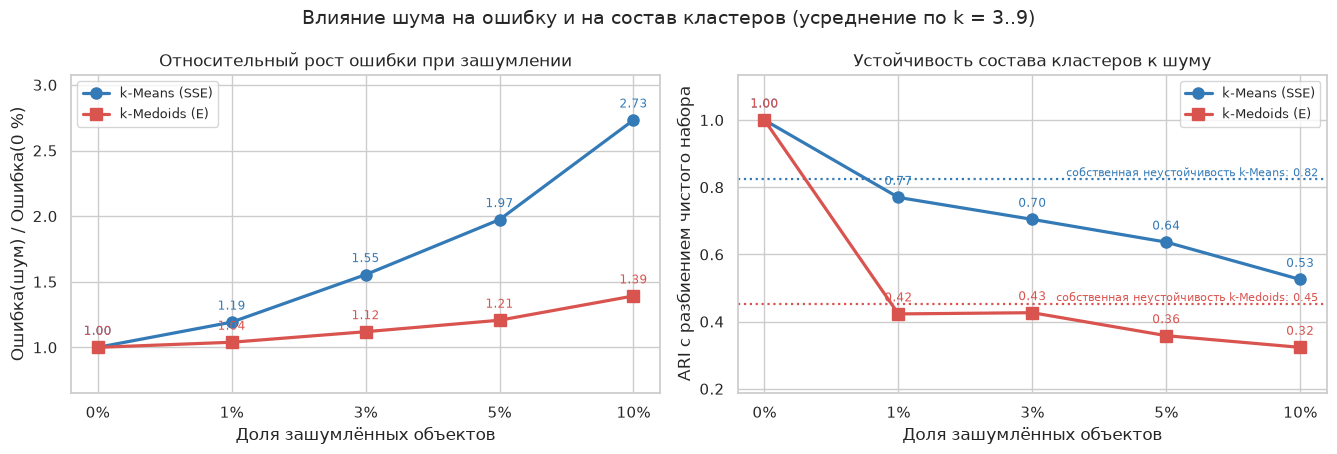

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

# слева: рост ошибки относительно незашумлённого набора
for ax, (value, ylabel, title) in zip(
        axes,
        [("ratio", "Ошибка(шум) / Ошибка(0 %)",
          "Относительный рост ошибки при зашумлении"),
         ("ari", "ARI с разбиением чистого набора",
          "Устойчивость состава кластеров к шуму")]):
    for algorithm, color, marker in (("kmeans", "#337ab7", "o"),
                                     ("kmedoids", "#d9534f", "s")):
        sub = df_noise[df_noise["algorithm"] == algorithm]
        base = sub[sub["noise"] == 0.0].set_index("k")["error"]
        agg = sub.groupby("noise").apply(
            lambda g: (g.set_index("k")["error"] / base).mean() if value == "ratio"
            else g["ari"].mean(), include_groups=False)
        ax.plot([f"{v:.0%}" for v in agg.index], agg.values, marker=marker,
                markersize=8, linewidth=2.3, color=color, label=ALG_LABEL[algorithm])
        for xi, yi in zip([f"{v:.0%}" for v in agg.index], agg.values):
            ax.annotate(f"{yi:.2f}", (xi, yi), fontsize=8.5, color=color,
                        textcoords="offset points", xytext=(0, 9), ha="center")
        if value == "ari":
            ax.axhline(self_ari[algorithm], color=color, linestyle=":", linewidth=1.6)
            ax.annotate(f"собственная неустойчивость "
                        f"{ALG_LABEL[algorithm].split(' (')[0]}: {self_ari[algorithm]:.2f}",
                        (0.985, self_ari[algorithm]), xycoords=("axes fraction", "data"),
                        fontsize=8, color=color, va="bottom", ha="right")
    ax.set_title(title, fontsize=12.5)
    ax.set_xlabel("Доля зашумлённых объектов")
    ax.set_ylabel(ylabel)
    ax.margins(y=0.2)
    ax.legend(fontsize=9.5)

fig.suptitle("Влияние шума на ошибку и на состав кластеров (усреднение по k = 3..9)",
             fontsize=13.5)
fig.tight_layout()
plt.show()

### Точечные графики при разной доле шума

Разбиения при $k = 4$ для каждой доли шума. Зашумлённые объекты обведены контуром; видно,
как выбросы оттягивают на себя центроиды и как ведёт себя при этом k-Medoids.

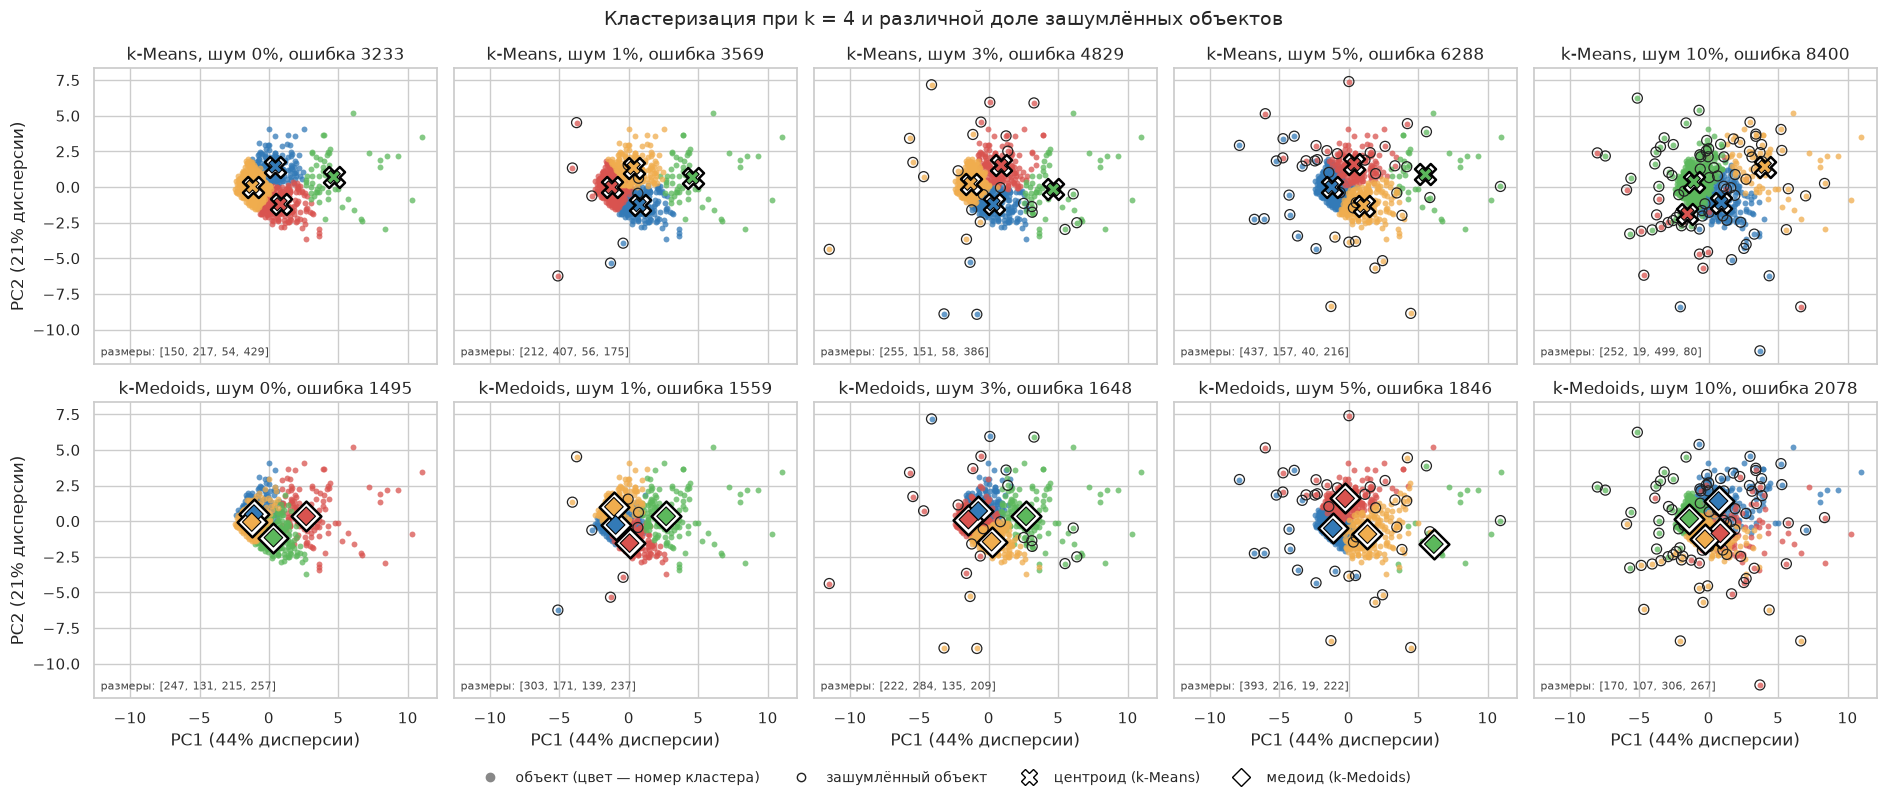

In [21]:
fig, axes = plt.subplots(2, len(NOISE_LEVELS), figsize=(19, 8.0),
                         sharex=True, sharey=True)      # общие оси -> панели сравнимы

for col, noise in enumerate(NOISE_LEVELS):
    for row, algorithm in enumerate(("kmeans", "kmedoids")):
        res = cluster(X, K_DEMO, algorithm, noise_fraction=noise)
        ax = axes[row, col]
        scatter_clusters(ax, project(res["X"]), res["labels"], project(res["centers"]),
                         noisy_idx=res["noisy_idx"], legend=False,
                         title=f"{ALG_LABEL[algorithm].split(' (')[0]}, шум {noise:.0%}, "
                               f"ошибка {res['error']:.0f}",
                         center_marker="X" if algorithm == "kmeans" else "D")
        ax.text(0.02, 0.03, f"размеры: {res['sizes'].tolist()}", transform=ax.transAxes,
                fontsize=8, color="#444444")
        if col:
            ax.set_ylabel("")
        if row == 0:
            ax.set_xlabel("")

handles = [plt.Line2D([], [], marker="o", linestyle="", color="#888888",
                      label="объект (цвет — номер кластера)"),
           plt.Line2D([], [], marker="o", linestyle="", markerfacecolor="none",
                      markeredgecolor="#222222", label="зашумлённый объект"),
           plt.Line2D([], [], marker="X", linestyle="", markerfacecolor="white",
                      markeredgecolor="black", markersize=11, label="центроид (k-Means)"),
           plt.Line2D([], [], marker="D", linestyle="", markerfacecolor="white",
                      markeredgecolor="black", markersize=9, label="медоид (k-Medoids)")]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, -0.005))
fig.suptitle(f"Кластеризация при k = {K_DEMO} и различной доле зашумлённых объектов",
             fontsize=14)
fig.tight_layout(rect=(0, 0.035, 1, 1))
plt.show()

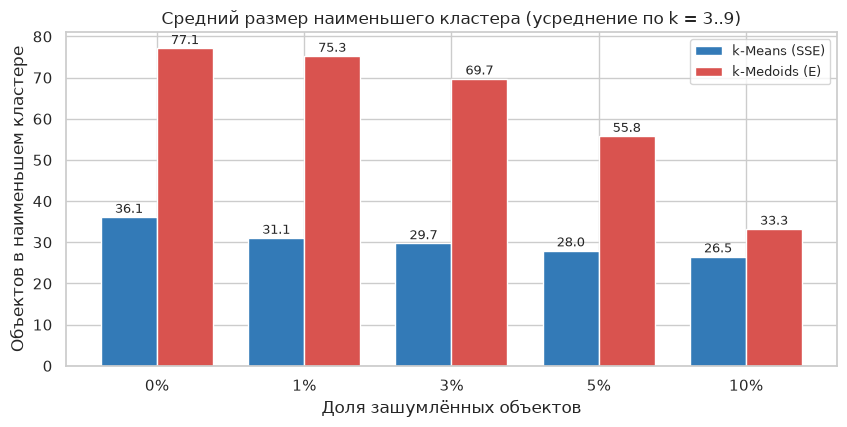

In [22]:
# Насколько сильно шум дробит разбиение: размер наименьшего кластера
fig, ax = plt.subplots(figsize=(8.6, 4.4))
width = 0.38
x = np.arange(len(NOISE_LEVELS))

for i, (algorithm, color) in enumerate((("kmeans", "#337ab7"), ("kmedoids", "#d9534f"))):
    sub = df_noise[df_noise["algorithm"] == algorithm].groupby("noise")["min_size"].mean()
    ax.bar(x + (i - 0.5) * width, sub.values, width, color=color,
           label=ALG_LABEL[algorithm])
    for xi, yi in zip(x + (i - 0.5) * width, sub.values):
        ax.annotate(f"{yi:.1f}", (xi, yi), fontsize=9, ha="center",
                    textcoords="offset points", xytext=(0, 3))

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.0%}" for v in NOISE_LEVELS])
ax.set_xlabel("Доля зашумлённых объектов")
ax.set_ylabel("Объектов в наименьшем кластере")
ax.set_title("Средний размер наименьшего кластера (усреднение по k = 3..9)", fontsize=12.5)
ax.legend(fontsize=9.5)
fig.tight_layout()
plt.show()

## 10. Выводы

### Структура набора и выбор числа кластеров

Кривые ошибки обоих алгоритмов имеют излом при $k = 4$ — ровно в этой точке кривая
максимально удалена от хорды, соединяющей её концы. Дальнейшее дробление даёт всё меньшую
отдачу: $SSE$ падает на 27 % при переходе от $k = 1$ к $k = 2$ и лишь на 4.8 % при переходе
от $k = 11$ к $k = 12$.

Полученные при $k = 4$ кластеры содержательно осмысленны:

| Кластер | Объектов | Портрет клиента | Доля банкротов |
|---|---|---|---|
| 3 | 429 | молодые (30.6 года), стаж 4.8 года, доход 28.6 K\$, долги минимальны | 0.238 |
| 1 | 217 | зрелые (42.4 года), стаж 15 лет, доход 68 K\$, долговая нагрузка 7.2 % | **0.083** |
| 0 | 150 | средний возраст, доход 37.8 K\$, но долговая нагрузка **19.5 %** | **0.512** |
| 2 | 54 | состоятельные: доход 127 K\$, долги 7.1 + 11.9, нагрузка 17.9 % | 0.409 |

Главная проверка осмысленности — атрибут `Defaulted`: он **не участвовал** в кластеризации,
но доля банкротов различается между кластерами в шесть раз (8.3 % против 51.2 %). Значит
разбиение по семи «анкетным» признакам улавливает реальную структуру кредитного риска.
Видно и то, какой признак за это отвечает: разделяет клиентов не доход сам по себе
(в кластерах 0 и 1 он отличается менее чем вдвое, а риск — в шесть раз), а отношение долга
к доходу `DebtIncomeRatio`. Это же читается на точечных графиках в исходных координатах:
в паре $Income \times DebtIncomeRatio$ кластеры разделяются почти горизонтальной линией.

### Сравнение k-Means и k-Medoids на незашумлённых данных

Каждый алгоритм выигрывает по своему функционалу, и это главный результат сравнения:
разбиение k-Means лучше по $SSE$ (3232.7 против 3417.2), разбиение k-Medoids — по $E$
(1495.4 против 1576.0). Напомним, что обе величины здесь посчитаны как характеристики
разбиения, с оптимальным для каждой меры центром, поэтому сравнение корректно. Ни один
из методов не доминирует: они решают разные задачи, и вопрос «какой лучше» без указания
меры качества смысла не имеет.

Согласие разбиений невелико — $ARI = 0.362$. Различие систематическое: k-Means выделяет
малочисленный кластер из 54 состоятельных клиентов, а k-Medoids такой кластер не создаёт
и вместо этого делит плотное ядро на четыре примерно равные части (247/131/215/257).
Причина — в виде минимизируемого функционала: в сумме квадратов удалённая группа объектов
даёт настолько большой штраф, что отдать ей отдельный центр выгодно; в сумме расстояний
вклад растёт лишь линейно, и такой «размен» не окупается. Содержательно это существенно:
кластер из 54 состоятельных клиентов с долей банкротов 41 % — осмысленная группа риска,
и k-Medoids её теряет.

### Влияние шума на величину ошибки

Ошибка монотонно растёт с долей зашумлённых объектов при любом $k$, но у алгоритмов
принципиально разный масштаб реакции: при 10 % шума $SSE$ алгоритма k-Means вырастает в
**2.73 раза**, а ошибка k-Medoids — лишь в **1.39 раза**. Причин две, и обе заложены в
определении методов:

* ошибка k-Means квадратична, поэтому объект, сдвинутый на $4\sigma$, вносит в неё вклад
  в 16 раз больший, чем в линейную меру k-Medoids;
* центроид — это среднее, и выброс смещает его в пустое пространство между кластерами;
  медоид же обязан быть реальным объектом и поэтому остаётся внутри плотной области.

Важно, что **форма** кривой «ошибка — $k$» при зашумлении сохраняется: кривые для разных
долей шума идут практически параллельно, шум добавляет к ошибке примерно постоянную
надбавку. Следовательно, выбор числа кластеров по методу локтя устойчив к шуму, даже когда
абсолютное значение ошибки уже сильно искажено.

### Влияние шума на состав кластеров

Величина ошибки и устойчивость самого разбиения — разные вещи, и здесь картина меняется
на противоположную. ARI с разбиением чистого набора у k-Means снижается с 1.00 до 0.53
при 10 % шума, а у k-Medoids падает до 0.42 уже при 1 %.

Напрямую эти числа сравнивать нельзя, и для этого в работу добавлено измерение
собственной неустойчивости алгоритмов. На **чистом** наборе два запуска k-Medoids с
разными стартовыми центрами дают разбиения с $ARI = 0.45$, тогда как у k-Means — 0.82.
То есть k-Medoids на этом наборе нестабилен и без всякого шума: в плотном ядре нет
естественных границ, задача имеет множество почти равноценных локальных минимумов, и
алгоритм каждый раз рассекает ядро по-новому. Его значение ARI под шумом (0.42–0.32)
практически совпадает с этим собственным уровнем, значит шум почти ничего не добавляет к
уже имеющемуся разбросу. У k-Means, наоборот, ARI при 1 % шума (0.77) близок к собственному
уровню 0.82, а начиная с 5 % (0.64) уверенно опускается ниже — это уже деградация именно
от шума.

Итог: **устойчивой к шуму у k-Medoids оказывается ошибка, а не разбиение**. Проявляется это
и в структуре результата: при 10 % шума k-Means начинает расходовать кластеры на выбросы —
при $k = 4$ он даёт разбиение 252/19/499/80, где один кластер из 19 объектов обслуживает
выбросы, а 499 клиентов (59 % набора) сваливаются в один; k-Medoids при тех же условиях
сохраняет 170/107/306/267. В среднем по $k = 3..9$ наименьший кластер у k-Medoids вдвое
крупнее (33.3 против 26.5 объектов при 10 % шума, 77.1 против 36.1 на чистых данных).

### Практические рекомендации

* На чистых или слабо зашумлённых данных (до 1–3 % выбросов) предпочтителен **k-Means**:
  он заметно устойчивее к выбору начальных центров (ARI между запусками 0.82 против 0.45),
  выделяет содержательно важные малочисленные группы и работает быстрее (0.08 с против
  0.15 с при $k = 4$, поскольку не требует матрицы попарных расстояний $n \times n$).
* При доле выбросов от 5 % и выше **k-Medoids** предпочтительнее: он не позволяет выбросам
  утянуть центры и не вырождает разбиение, жертвуя кластером ради нескольких объектов.
* k-Medoids на данных без выраженных границ следует запускать с большим числом рестартов и
  проверять устойчивость разбиения, а не только значение ошибки: низкий ARI между запусками
  — сигнал, что найденное разбиение является одним из многих равноценных.
* Число кластеров по методу локтя можно определять и на зашумлённых данных — положение
  излома шум не смещает.